# Skeleton-Based Action Recognition — LSTM-Transformer Hybrid

**Dataset**: NTU RGB+D 60 — HRNet 2D pose (17 COCO joints, `ntu60_hrnet.pkl`)  
**Model**: Bi-LSTM → Transformer Encoder  
**Protocol**: Cross-Subject (CS)

### Evaluation Metrics
| Metric | What it measures |
|--------|------------------|
| **Top-1 Accuracy** | Exact match — did the model predict the correct class? |
| **Top-5 Accuracy** | Was the correct class in the model's top 5 predictions? |
| **Mean Class Accuracy (MCA)** | Average per-class recall — treats rare/common classes equally |
| **Weighted F1-Score** | Harmonic mean of precision & recall, weighted by class frequency |
| **Cohen's Kappa** | Agreement beyond random chance (0 = random, 1 = perfect) |
| **Confusion Matrix** | Which classes get confused with each other |
| **Per-Class Accuracy** | Accuracy breakdown for every action |
| **t-SNE** | Are learned features clustered well by action class? |

## 1. Setup

In [1]:
!pip install torch torchvision tqdm matplotlib seaborn scikit-learn -q

In [2]:
import os
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    confusion_matrix, classification_report,
    top_k_accuracy_score, accuracy_score,
    f1_score, cohen_kappa_score
)
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## 2. Download Dataset to Colab

In [3]:
# Downloads ntu60_hrnet.pkl from Google Drive into Colab's local storage
# Only runs once per session — skips if file already exists
import os
if not os.path.exists('ntu60_hrnet.pkl'):
    !pip install gdown -q
    !gdown 15d929Os1ytQ5zLb7ptwqhwGdgPl5JCMR -O ntu60_hrnet.pkl
    print(f'Downloaded: {os.path.getsize("ntu60_hrnet.pkl") / (1024**2):.1f} MB')
else:
    print('File already exists, skipping download.')

Downloading...
From (original): https://drive.google.com/uc?id=15d929Os1ytQ5zLb7ptwqhwGdgPl5JCMR
From (redirected): https://drive.google.com/uc?id=15d929Os1ytQ5zLb7ptwqhwGdgPl5JCMR&confirm=t&uuid=afff1d0a-4ba2-46a5-8a82-6272df558d3f
To: /content/ntu60_hrnet.pkl
100% 705M/705M [00:15<00:00, 45.4MB/s]
Downloaded: 672.7 MB


## 3. Configuration

In [4]:
# ============================================================
# SET THIS PATH to your ntu60_hrnet.pkl file
# ============================================================
PKL_PATH = './ntu60_hrnet.pkl'   # <-- CHANGE THIS if needed

NUM_JOINTS = 17          # COCO-17 format
MAX_BODIES = 2
MAX_FRAMES = 300
NUM_CLASSES = 60
IMG_W, IMG_H = 1920, 1080

# COCO-17 joint names
JOINT_NAMES = [
    'nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
    'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
    'left_knee', 'right_knee', 'left_ankle', 'right_ankle'
]

# Parent joint for each joint (used to compute bone features)
JOINT_PARENTS = [
    0,   # 0  nose → self
    0,   # 1  left_eye → nose
    0,   # 2  right_eye → nose
    1,   # 3  left_ear → left_eye
    2,   # 4  right_ear → right_eye
    0,   # 5  left_shoulder → nose
    0,   # 6  right_shoulder → nose
    5,   # 7  left_elbow → left_shoulder
    6,   # 8  right_elbow → right_shoulder
    7,   # 9  left_wrist → left_elbow
    8,   # 10 right_wrist → right_elbow
    5,   # 11 left_hip → left_shoulder
    6,   # 12 right_hip → right_shoulder
    11,  # 13 left_knee → left_hip
    12,  # 14 right_knee → right_hip
    13,  # 15 left_ankle → left_knee
    14,  # 16 right_ankle → right_knee
]

# COCO-17 skeleton edges (for visualization)
SKELETON_EDGES = [
    (0, 1), (0, 2), (1, 3), (2, 4),       # head
    (5, 6),                                 # shoulders
    (5, 7), (7, 9),                        # left arm
    (6, 8), (8, 10),                       # right arm
    (5, 11), (6, 12),                      # torso
    (11, 12),                              # hips
    (11, 13), (13, 15),                    # left leg
    (12, 14), (14, 16),                    # right leg
]

# Training hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 60
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
WARMUP_EPOCHS = 5

NTU_ACTIONS = {
    0: 'drink water', 1: 'eat meal/snack', 2: 'brushing teeth',
    3: 'brushing hair', 4: 'drop', 5: 'pickup',
    6: 'throw', 7: 'sitting down', 8: 'standing up',
    9: 'clapping', 10: 'reading', 11: 'writing',
    12: 'tear up paper', 13: 'wear jacket', 14: 'take off jacket',
    15: 'wear a shoe', 16: 'take off a shoe', 17: 'wear on glasses',
    18: 'take off glasses', 19: 'put on a hat/cap',
    20: 'take off a hat/cap', 21: 'cheer up', 22: 'hand waving',
    23: 'kicking something', 24: 'reach into pocket',
    25: 'hopping', 26: 'jump up', 27: 'make a phone call',
    28: 'playing with phone', 29: 'typing on keyboard',
    30: 'point to something', 31: 'taking a selfie',
    32: 'check time (watch)', 33: 'rub two hands together',
    34: 'nod head/bow', 35: 'shake head', 36: 'wipe face',
    37: 'salute', 38: 'put palms together', 39: 'cross hands in front',
    40: 'sneeze/cough', 41: 'staggering', 42: 'falling',
    43: 'touch head', 44: 'touch chest', 45: 'touch back',
    46: 'touch neck', 47: 'nausea/vomiting', 48: 'fan self',
    49: 'punch/slap other', 50: 'kicking other',
    51: 'pushing other', 52: 'pat on back',
    53: 'point finger at other', 54: 'hugging',
    55: 'giving something', 56: 'touch pocket',
    57: 'handshaking', 58: 'walking towards', 59: 'walking apart'
}

## 4. Load Dataset

In [5]:
print('Loading pickle file...')
with open(PKL_PATH, 'rb') as f:
    dataset = pickle.load(f)

split = dataset['split']
annotations = dataset['annotations']

print(f'Total samples:  {len(annotations)}')
print(f'Train (xsub):   {len(split["xsub_train"])}')
print(f'Test  (xsub):   {len(split["xsub_val"])}')
print(f'Classes:        {NUM_CLASSES}')

Loading pickle file...
Total samples:  56578
Train (xsub):   40091
Test  (xsub):   16487
Classes:        60


## 5. Data Exploration

Frame lengths — min: 32, max: 300, mean: 85, median: 76
Multi-body samples: 10337 / 56578


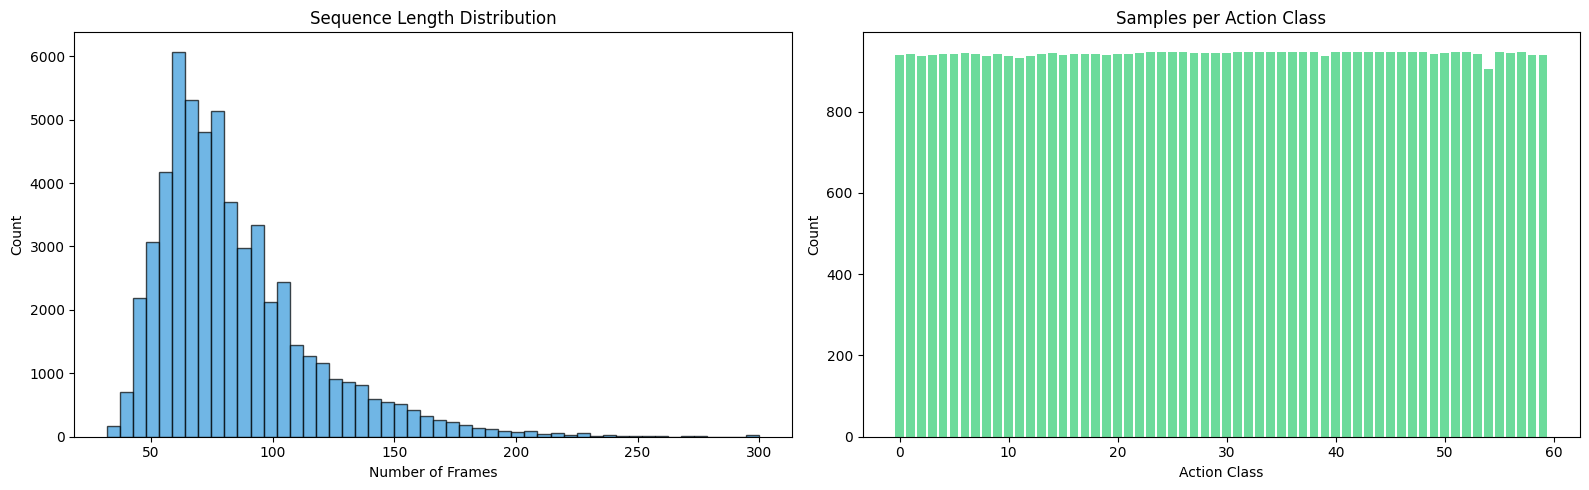

In [6]:
# Basic stats
frame_lengths = [a['total_frames'] for a in annotations]
labels_all = [a['label'] for a in annotations]
body_counts = [a['keypoint'].shape[0] for a in annotations]

print(f'Frame lengths — min: {min(frame_lengths)}, max: {max(frame_lengths)}, '
      f'mean: {np.mean(frame_lengths):.0f}, median: {np.median(frame_lengths):.0f}')
print(f'Multi-body samples: {sum(1 for b in body_counts if b > 1)} / {len(annotations)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(frame_lengths, bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[0].set_xlabel('Number of Frames')
axes[0].set_ylabel('Count')
axes[0].set_title('Sequence Length Distribution')

class_counts = Counter(labels_all)
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]
axes[1].bar(classes, counts, alpha=0.7, color='#2ecc71')
axes[1].set_xlabel('Action Class')
axes[1].set_ylabel('Count')
axes[1].set_title('Samples per Action Class')

plt.tight_layout()
plt.show()

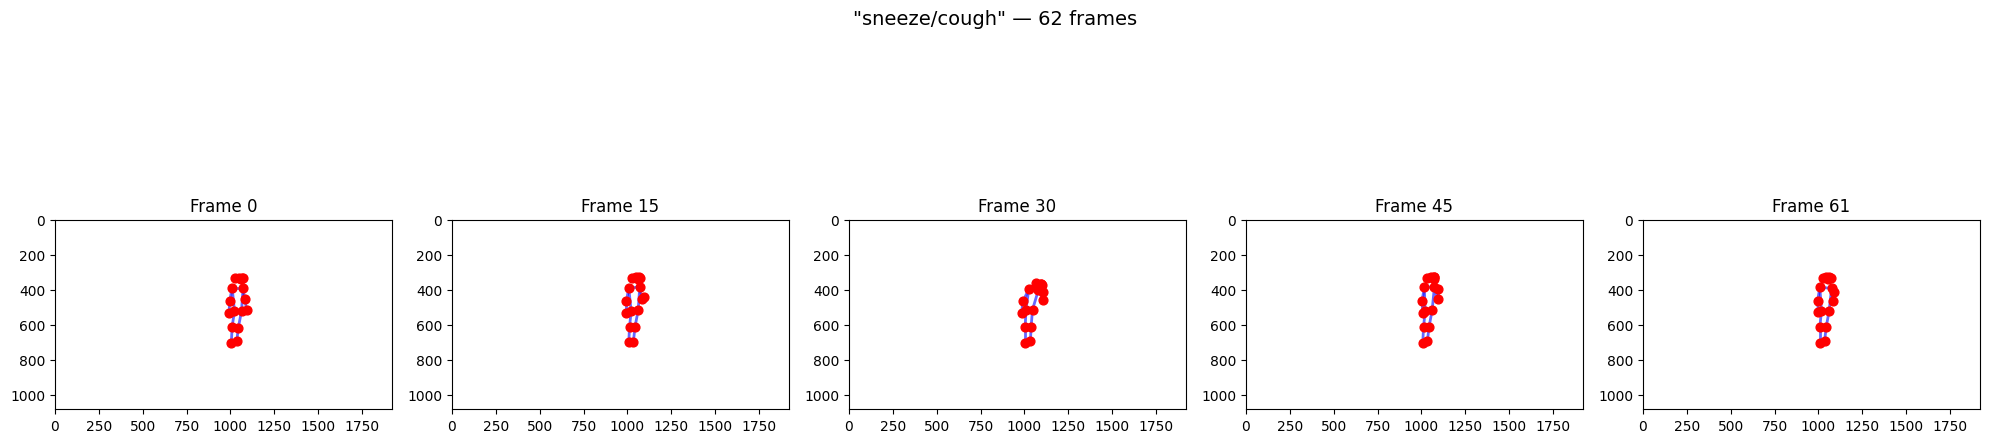

In [7]:
# Visualize a skeleton sequence
def plot_skeleton_2d(keypoint, frame_idx=0, body_idx=0, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 8))
    x = keypoint[body_idx, frame_idx, :, 0]
    y = keypoint[body_idx, frame_idx, :, 1]

    for (j1, j2) in SKELETON_EDGES:
        ax.plot([x[j1], x[j2]], [y[j1], y[j2]], 'b-', linewidth=2, alpha=0.6)
    ax.scatter(x, y, c='red', s=40, zorder=5)
    ax.set_xlim(0, IMG_W)
    ax.set_ylim(IMG_H, 0)
    ax.set_aspect('equal')
    ax.set_title(f'Frame {frame_idx}')

sample_ann = annotations[100]
kp = sample_ann['keypoint']
n_frames = sample_ann['total_frames']
frame_indices = np.linspace(0, n_frames - 1, 5, dtype=int)

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle(f'"{NTU_ACTIONS[sample_ann["label"]]}" — {n_frames} frames', fontsize=14)
for fi, ax in zip(frame_indices, axes):
    plot_skeleton_2d(kp, frame_idx=fi, body_idx=0, ax=ax)
plt.tight_layout()
plt.show()

## 6. Preprocessing

We build **7 input channels per joint** to give the model rich information:

| Channel | What it captures |
|---------|------------------|
| `x, y` (normalized) | Joint position, centered on hip, scaled by torso length |
| `confidence` | HRNet detection reliability — model learns to ignore noisy joints |
| `vel_x, vel_y` | Frame-to-frame velocity — captures motion dynamics |
| `bone_x, bone_y` | Relative position to parent joint — captures body structure |

**Memory-efficient approach**: features are computed on-the-fly inside the Dataset, not pre-stored in RAM.

In [8]:
def preprocess_sample(ann):
    """
    Convert a single annotation to a feature tensor.
    Input:  keypoint (M, T, 17, 2), keypoint_score (M, T, 17)
    Output: (7, MAX_FRAMES, 17, 2) — 7 channels, padded to MAX_FRAMES
    """
    kp = ann['keypoint'].astype(np.float32)        # (M, T, 17, 2)
    score = ann['keypoint_score'].astype(np.float32)  # (M, T, 17)
    M, T, V, C = kp.shape

    # Pad to MAX_BODIES if single body
    if M < MAX_BODIES:
        pad_kp = np.zeros((MAX_BODIES - M, T, V, C), dtype=np.float32)
        pad_sc = np.zeros((MAX_BODIES - M, T, V), dtype=np.float32)
        kp = np.concatenate([kp, pad_kp], axis=0)
        score = np.concatenate([score, pad_sc], axis=0)

    # --- Normalize: center on hip, scale by torso ---
    hip = (kp[:, :, 11:12, :] + kp[:, :, 12:13, :]) / 2.0
    kp_centered = kp - hip

    shoulder = (kp[:, :, 5:6, :] + kp[:, :, 6:7, :]) / 2.0
    torso = np.sqrt(((shoulder - hip) ** 2).sum(axis=-1, keepdims=True))
    torso = np.clip(torso, a_min=1.0, a_max=None)
    torso_mean = torso.mean(axis=1, keepdims=True)
    torso_mean = np.clip(torso_mean, a_min=10.0, a_max=None)
    kp_norm = kp_centered / torso_mean

    # --- Velocity: temporal difference ---
    vel = np.zeros_like(kp_norm)
    vel[:, 1:, :, :] = kp_norm[:, 1:, :, :] - kp_norm[:, :-1, :, :]

    # --- Bone features: joint minus parent joint ---
    bone = np.zeros_like(kp_norm)
    for j in range(V):
        bone[:, :, j, :] = kp_norm[:, :, j, :] - kp_norm[:, :, JOINT_PARENTS[j], :]

    # --- Confidence as a channel ---
    conf = score[:, :, :, np.newaxis]

    # Stack all channels: (M, T, 17, 7)
    features = np.concatenate([kp_norm, conf, vel, bone], axis=-1)

    # Pad or truncate time to MAX_FRAMES
    if T >= MAX_FRAMES:
        features = features[:, :MAX_FRAMES, :, :]
    else:
        pad = np.zeros((MAX_BODIES, MAX_FRAMES - T, V, 7), dtype=np.float32)
        features = np.concatenate([features, pad], axis=1)

    # Reshape to (7, MAX_FRAMES, 17, 2) — channels first
    features = features.transpose(3, 1, 2, 0)  # (7, T, V, M)

    return features

# Quick test on one sample
test_feat = preprocess_sample(annotations[0])
print(f'Feature shape per sample: {test_feat.shape}  (C=7, T={MAX_FRAMES}, V=17, M=2)')
print('Preprocessing will run on-the-fly inside the DataLoader (saves RAM).')

Feature shape per sample: (7, 300, 17, 2)  (C=7, T=300, V=17, M=2)
Preprocessing will run on-the-fly inside the DataLoader (saves RAM).


## 7. Dataset & DataLoader

In [9]:
class SkeletonDataset(Dataset):
    def __init__(self, keys, ann_lookup, augment=False):
        self.samples = [ann_lookup[k] for k in keys if k in ann_lookup]
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ann = self.samples[idx]
        feat = preprocess_sample(ann)  # (7, T, V, M) — computed on-the-fly
        label = ann['label']

        if self.augment:
            feat = self._augment(feat, ann['total_frames'])

        return torch.FloatTensor(feat), torch.tensor(label, dtype=torch.long)

    def _augment(self, feat, n_frames):
        # Random scale (0.9 - 1.1)
        scale = np.random.uniform(0.9, 1.1)
        for ch in [0, 1, 3, 4, 5, 6]:  # x, y, vel_x, vel_y, bone_x, bone_y
            feat[ch] *= scale

        # Random 2D rotation (-15 to +15 degrees)
        angle = np.random.uniform(-15, 15) * np.pi / 180
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        for ch_x, ch_y in [(0, 1), (3, 4), (5, 6)]:  # position, velocity, bone
            x, y = feat[ch_x].copy(), feat[ch_y].copy()
            feat[ch_x] = x * cos_a - y * sin_a
            feat[ch_y] = x * sin_a + y * cos_a

        # Random temporal shift
        T = min(n_frames, MAX_FRAMES)
        if T > 10:
            shift = np.random.randint(-5, 6)
            if shift != 0:
                feat[:, :T, :, :] = np.roll(feat[:, :T, :, :], shift, axis=1)

        return feat


# Build lookup: frame_dir → annotation
ann_lookup = {a['frame_dir']: a for a in annotations}

train_dataset = SkeletonDataset(split['xsub_train'], ann_lookup, augment=True)
test_dataset = SkeletonDataset(split['xsub_val'], ann_lookup, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset)} samples, {len(train_loader)} batches')
print(f'Test:  {len(test_dataset)} samples, {len(test_loader)} batches')

Train: 40091 samples, 626 batches
Test:  16487 samples, 258 batches


## 8. LSTM-Transformer Model

```
Input: (N, 7, 300, 17, 2)
  ↓ flatten joints+bodies → (N, 300, 238)
  ↓ Linear projection    → (N, 300, 256)
  ↓ Bi-LSTM (2 layers)   → local temporal features
  ↓ Project back          → (N, 300, 256)
  ↓ + Positional Encoding
  ↓ Prepend [CLS] token  → (N, 301, 256)
  ↓ Transformer Encoder (4 layers, 8 heads)
  ↓ [CLS] output         → (N, 256)
  ↓ FC                   → (N, 60)
```

In [10]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class LSTMTransformer(nn.Module):
    def __init__(self, input_size, d_model=256, lstm_hidden=128, lstm_layers=2,
                 nhead=8, num_transformer_layers=4, dim_feedforward=512,
                 num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_size, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )
        self.lstm_proj = nn.Sequential(
            nn.Linear(lstm_hidden * 2, d_model),
            nn.LayerNorm(d_model),
        )

        self.pos_encoder = PositionalEncoding(d_model, max_len=MAX_FRAMES + 1, dropout=dropout)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_transformer_layers,
            norm=nn.LayerNorm(d_model),
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x):
        # x: (N, C, T, V, M)
        N, C, T, V, M = x.shape
        x_flat = x.permute(0, 2, 1, 3, 4).contiguous().view(N, T, -1)  # (N, T, C*V*M)

        # Padding mask: frames where ALL features are zero
        pad_mask = (x_flat.abs().sum(dim=-1) == 0)  # (N, T)

        x = self.input_proj(x_flat)
        x, _ = self.lstm(x)
        x = self.lstm_proj(x)

        cls = self.cls_token.expand(N, -1, -1)
        x = torch.cat([cls, x], dim=1)            # (N, T+1, d_model)

        # Extend mask: CLS token is never masked
        cls_mask = torch.zeros(N, 1, dtype=torch.bool, device=x.device)
        full_mask = torch.cat([cls_mask, pad_mask], dim=1)  # (N, T+1)

        x = self.pos_encoder(x)
        x = self.transformer_encoder(x, src_key_padding_mask=full_mask)

        return self.head(x[:, 0, :])  # CLS token


INPUT_SIZE = 7 * NUM_JOINTS * MAX_BODIES  # 7 * 17 * 2 = 238

model = LSTMTransformer(
    input_size=INPUT_SIZE,
    d_model=256,
    lstm_hidden=128,
    lstm_layers=2,
    nhead=8,
    num_transformer_layers=4,
    dim_feedforward=512,
    num_classes=NUM_CLASSES,
    dropout=0.3,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

/tmp/ipykernel_6481/3455055019.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(


Total parameters:     3,043,132
Trainable parameters: 3,043,132


## 9. Training

In [12]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
        correct += (logits.argmax(1) == batch_y).sum().item()
        total += batch_x.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        total_loss += loss.item() * batch_x.size(0)
        correct += (logits.argmax(1) == batch_y).sum().item()
        total += batch_x.size(0)

    return total_loss / total, correct / total

In [13]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

# Warmup + Cosine Annealing
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS]
)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'lr': []}
best_acc = 0

print('='*65)
print('Training LSTM-Transformer')
print('='*65)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'lstm_transformer_best.pth')


    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{NUM_EPOCHS}  '
              f'Train: {train_loss:.4f} / {train_acc:.4f}  |  '
              f'Test: {test_loss:.4f} / {test_acc:.4f}  '
              f'(best: {best_acc:.4f})  lr: {current_lr:.6f}')

print(f'\nBest Test Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)')

Training LSTM-Transformer
Epoch   1/60  Train: 3.3388 / 0.1474  |  Test: 2.5672 / 0.3784  (best: 0.3784)  lr: 0.000050
Epoch   5/60  Train: 1.4416 / 0.7421  |  Test: 1.4294 / 0.7494  (best: 0.7494)  lr: 0.000410
Epoch  10/60  Train: 1.1511 / 0.8484  |  Test: 1.2758 / 0.8119  (best: 0.8119)  lr: 0.000494
Epoch  15/60  Train: 1.0204 / 0.8950  |  Test: 1.2304 / 0.8325  (best: 0.8325)  lr: 0.000468
Epoch  20/60  Train: 0.9438 / 0.9238  |  Test: 1.2423 / 0.8413  (best: 0.8436)  lr: 0.000424
Epoch  25/60  Train: 0.8884 / 0.9433  |  Test: 1.2270 / 0.8510  (best: 0.8520)  lr: 0.000367
Epoch  30/60  Train: 0.8467 / 0.9585  |  Test: 1.2299 / 0.8542  (best: 0.8612)  lr: 0.000300
Epoch  35/60  Train: 0.8110 / 0.9716  |  Test: 1.2280 / 0.8643  (best: 0.8643)  lr: 0.000229
Epoch  40/60  Train: 0.7807 / 0.9836  |  Test: 1.2445 / 0.8676  (best: 0.8688)  lr: 0.000159
Epoch  45/60  Train: 0.7567 / 0.9923  |  Test: 1.2845 / 0.8677  (best: 0.8741)  lr: 0.000097
Epoch  50/60  Train: 0.7466 / 0.9956  |  Tes

## 10. Training Curves

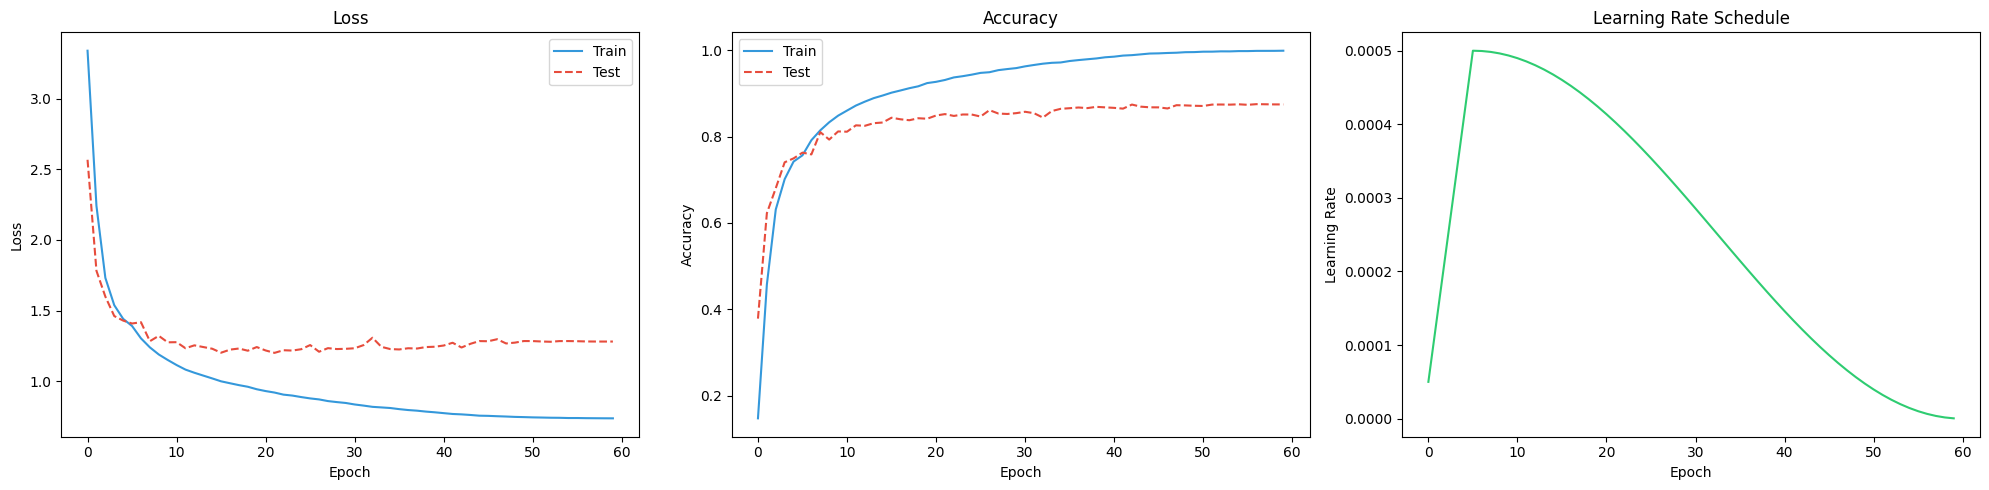

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(history['train_loss'], label='Train', color='#3498db')
axes[0].plot(history['test_loss'], label='Test', color='#e74c3c', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train', color='#3498db')
axes[1].plot(history['test_acc'], label='Test', color='#e74c3c', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy'); axes[1].legend()

axes[2].plot(history['lr'], color='#2ecc71')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')

plt.tight_layout()
plt.show()

---
## 11. Evaluation — All Metrics

| Metric | Why it matters |
|--------|----------------|
| **Top-1 Accuracy** | Primary metric — did the model get it right? |
| **Top-5 Accuracy** | Is the correct answer at least in the top 5? Shows if the model is "close" |
| **Mean Class Accuracy** | Treats every action equally — not inflated by common classes |
| **Weighted F1** | Balances precision & recall, weighted by class size |
| **Cohen's Kappa** | How much better than random guessing? (0=random, 1=perfect) |

In [15]:
# Load best checkpoint
model.load_state_dict(torch.load('lstm_transformer_best.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []
all_probs = []
features_buffer = []

def hook_fn(module, input, output):
    features_buffer.append(input[0].cpu().numpy())

hook = model.head[-1].register_forward_hook(hook_fn)

with torch.no_grad():
    for batch_x, batch_y in tqdm(test_loader, desc='Evaluating'):
        batch_x = batch_x.to(device)
        logits = model(batch_x)
        probs = F.softmax(logits, dim=1)

        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(batch_y.numpy())
        all_probs.extend(probs.cpu().numpy())

hook.remove()
all_features = np.concatenate(features_buffer, axis=0)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

Evaluating: 100%|██████████| 258/258 [00:23<00:00, 10.92it/s]


In [16]:
# === Core Metrics ===
top1 = accuracy_score(all_labels, all_preds)
top5 = top_k_accuracy_score(all_labels, all_probs, k=5)

# Mean Class Accuracy: average of per-class recall
report_dict = classification_report(all_labels, all_preds, output_dict=True)
per_class_recall = [report_dict[str(i)]['recall'] for i in range(NUM_CLASSES)]
mca = np.mean(per_class_recall)

# Weighted F1
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

# Cohen's Kappa
kappa = cohen_kappa_score(all_labels, all_preds)

print('╔══════════════════════════════════════════════════╗')
print('║       LSTM-Transformer — Evaluation Results     ║')
print('║              Cross-Subject Protocol             ║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  Top-1 Accuracy:         {top1:.4f}  ({top1*100:.2f}%)     ║')
print(f'║  Top-5 Accuracy:         {top5:.4f}  ({top5*100:.2f}%)     ║')
print(f'║  Mean Class Accuracy:    {mca:.4f}  ({mca*100:.2f}%)     ║')
print(f'║  Weighted F1-Score:      {weighted_f1:.4f}               ║')
print(f'║  Cohen\'s Kappa:          {kappa:.4f}               ║')
print('╚══════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════╗
║       LSTM-Transformer — Evaluation Results     ║
║              Cross-Subject Protocol             ║
╠══════════════════════════════════════════════════╣
║  Top-1 Accuracy:         0.8751  (87.51%)     ║
║  Top-5 Accuracy:         0.9683  (96.83%)     ║
║  Mean Class Accuracy:    0.8749  (87.49%)     ║
║  Weighted F1-Score:      0.8753               ║
║  Cohen's Kappa:          0.8729               ║
╚══════════════════════════════════════════════════╝


## 12. Per-Class Accuracy

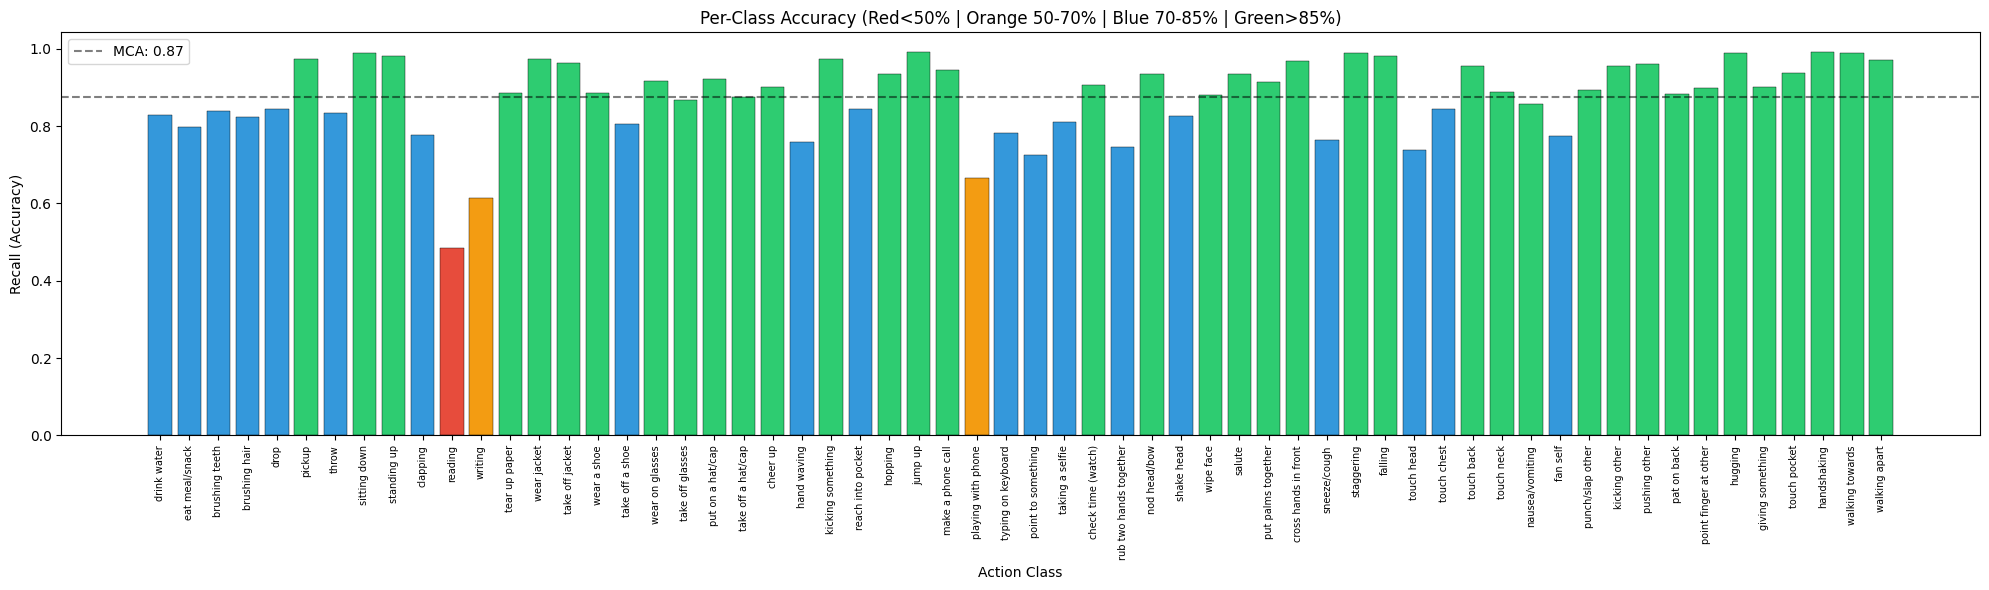

5 Hardest Actions:
  A11 reading                        → 0.4835
  A12 writing                        → 0.6140
  A29 playing with phone             → 0.6655
  A31 point to something             → 0.7246
  A44 touch head                     → 0.7391

5 Easiest Actions:
  A08 sitting down                   → 0.9890
  A55 hugging                        → 0.9891
  A42 staggering                     → 0.9891
  A27 jump up                        → 0.9928
  A58 handshaking                    → 0.9928


In [17]:
fig, ax = plt.subplots(figsize=(20, 6))
colors = ['#e74c3c' if a < 0.5 else '#f39c12' if a < 0.7 else '#3498db' if a < 0.85 else '#2ecc71'
          for a in per_class_recall]
ax.bar(range(NUM_CLASSES), per_class_recall, color=colors, edgecolor='black', linewidth=0.3)
ax.set_xlabel('Action Class')
ax.set_ylabel('Recall (Accuracy)')
ax.set_title('Per-Class Accuracy (Red<50% | Orange 50-70% | Blue 70-85% | Green>85%)')
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([NTU_ACTIONS[i] for i in range(NUM_CLASSES)], rotation=90, fontsize=7)
ax.axhline(y=mca, color='black', linestyle='--', alpha=0.5, label=f'MCA: {mca:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

sorted_idx = np.argsort(per_class_recall)
print('5 Hardest Actions:')
for i in sorted_idx[:5]:
    print(f'  A{i+1:02d} {NTU_ACTIONS[i]:30s} → {per_class_recall[i]:.4f}')
print('\n5 Easiest Actions:')
for i in sorted_idx[-5:]:
    print(f'  A{i+1:02d} {NTU_ACTIONS[i]:30s} → {per_class_recall[i]:.4f}')

## 13. Confusion Matrix

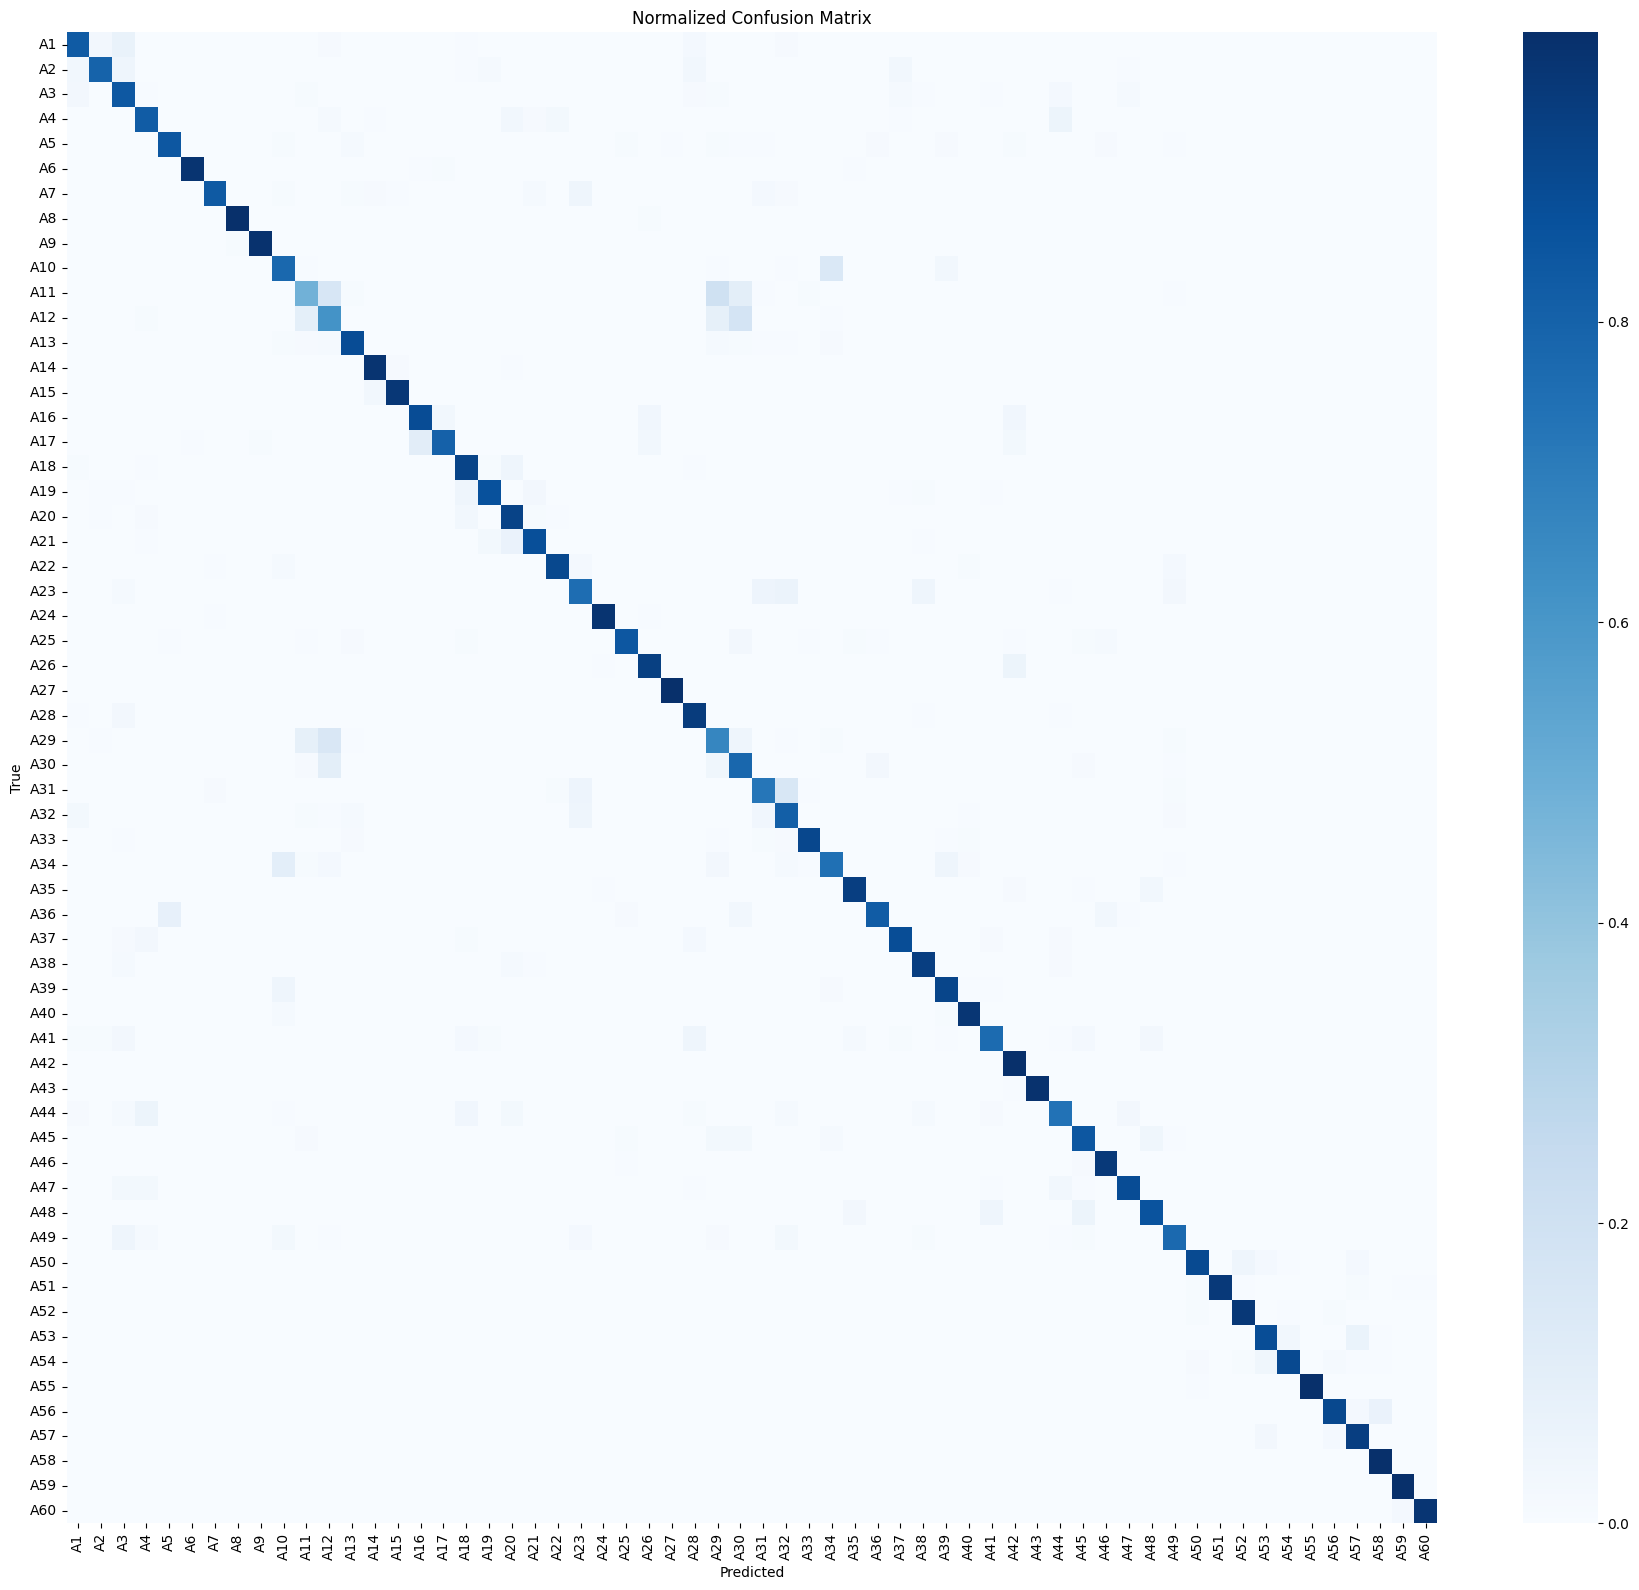


Most Confused Pairs (off-diagonal):
  reading                   → playing with phone         (20.5%)
  writing                   → typing on keyboard         (17.6%)
  reading                   → writing                    (16.1%)
  point to something        → taking a selfie            (15.6%)
  playing with phone        → writing                    (15.3%)
  clapping                  → rub two hands together     (14.7%)
  take off a shoe           → wear a shoe                (10.6%)
  reading                   → typing on keyboard         (10.3%)
  typing on keyboard        → writing                    (10.2%)
  rub two hands together    → clapping                   (9.8%)


In [18]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm_norm, annot=False, cmap='Blues',
            xticklabels=[f'A{i+1}' for i in range(NUM_CLASSES)],
            yticklabels=[f'A{i+1}' for i in range(NUM_CLASSES)], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Normalized Confusion Matrix')
plt.tight_layout()
plt.show()

# Top confused pairs
print('\nMost Confused Pairs (off-diagonal):')
np.fill_diagonal(cm_norm, 0)
confused = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm_norm[i, j] > 0.05:
            confused.append((cm_norm[i, j], i, j))
confused.sort(reverse=True)
for score, true, pred in confused[:10]:
    print(f'  {NTU_ACTIONS[true]:25s} → {NTU_ACTIONS[pred]:25s}  ({score:.1%})')

## 14. t-SNE Feature Visualization

Computing t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


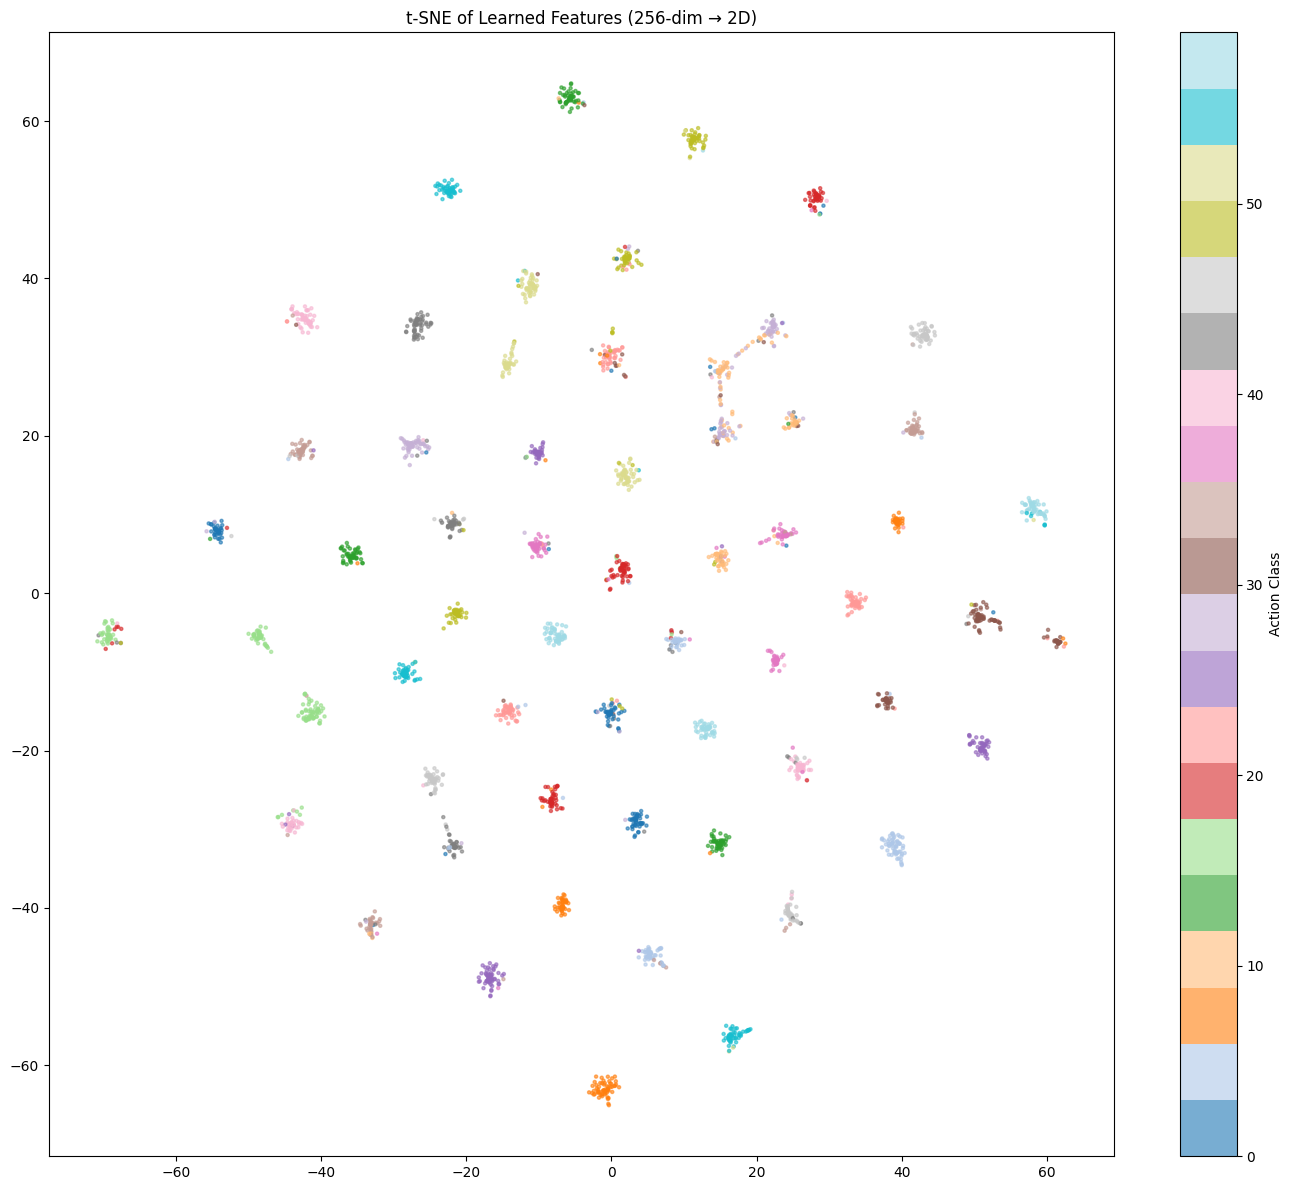

In [19]:
print('Computing t-SNE...')
n_tsne = min(3000, len(all_features))
indices = np.random.choice(len(all_features), n_tsne, replace=False)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
features_2d = tsne.fit_transform(all_features[indices])

fig, ax = plt.subplots(figsize=(14, 12))
scatter = ax.scatter(
    features_2d[:, 0], features_2d[:, 1],
    c=all_labels[indices], cmap='tab20', s=5, alpha=0.6
)
ax.set_title('t-SNE of Learned Features (256-dim → 2D)')
plt.colorbar(scatter, ax=ax, label='Action Class')
plt.tight_layout()
plt.show()

## 15. Full Classification Report

In [20]:
print(classification_report(
    all_labels, all_preds,
    target_names=[f'A{i+1:02d} {NTU_ACTIONS[i]}' for i in range(NUM_CLASSES)],
    digits=4
))

                            precision    recall  f1-score   support

           A01 drink water     0.8566    0.8285    0.8423       274
        A02 eat meal/snack     0.9012    0.7964    0.8456       275
        A03 brushing teeth     0.7090    0.8388    0.7685       273
         A04 brushing hair     0.8065    0.8242    0.8152       273
                  A05 drop     0.8958    0.8436    0.8689       275
                A06 pickup     0.9889    0.9745    0.9817       275
                 A07 throw     0.9463    0.8327    0.8859       275
          A08 sitting down     0.9854    0.9890    0.9872       273
           A09 standing up     0.9853    0.9817    0.9835       273
              A10 clapping     0.7465    0.7766    0.7612       273
               A11 reading     0.6286    0.4835    0.5466       273
               A12 writing     0.5405    0.6140    0.5749       272
         A13 tear up paper     0.8791    0.8856    0.8824       271
           A14 wear jacket     0.9371    0.9745

In [21]:
from google.colab import files
files.download('lstm_transformer_best.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import json

results = {
    "best_accuracy": best_acc,
    "train_history": history
}

with open("results.json", "w") as f:
    json.dump(results, f)

In [23]:
files.download('results.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

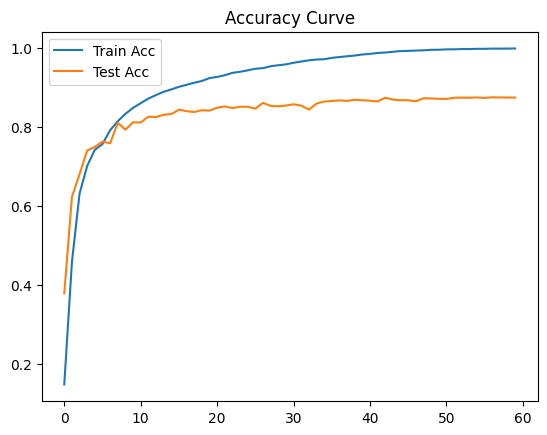

In [24]:
import matplotlib.pyplot as plt

plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.legend()
plt.title('Accuracy Curve')
plt.savefig('accuracy_plot.png')

In [25]:
files.download('accuracy_plot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels, all_preds,
    target_names=[f'A{i+1:02d} {NTU_ACTIONS[i]}' for i in range(NUM_CLASSES)],
    digits=4
)

with open("classification_report.txt", "w") as f:
    f.write(report)

In [27]:
files.download('classification_report.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 16. Summary & Metric Explanations

### What Each Metric Tells You

| Metric | Good If | Worried If |
|--------|---------|------------|
| **Top-1** | > 82% | < 75% — check preprocessing |
| **Top-5** | > 95% | < 90% — model is far off, not just confused between similar actions |
| **MCA** | Close to Top-1 | Much lower than Top-1 — model is failing on rare classes |
| **Weighted F1** | > 0.82 | < 0.75 — precision or recall dropping for some classes |
| **Kappa** | > 0.80 | < 0.70 — not much better than random for some classes |

### Accuracy Boosters Used
1. **7-channel input** (x, y, confidence, velocity, bone) — richer features than raw coordinates
2. **Hip-center + torso-scale normalization** — position/scale invariance
3. **Padding mask in Transformer** — attention ignores zero-padded frames
4. **Data augmentation** — random scale, rotation, temporal shift
5. **Label smoothing** (0.1) — prevents overconfident predictions
6. **Warmup + cosine LR** — stable training from the start
7. **Gradient clipping** — prevents Transformer gradient explosions